In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
path = "UGs.csv"
df = pd.read_csv(path)

# converter data
df["Data"] = pd.to_datetime(df["Date mais recente"])

# filtrar a partir de junho de 2017
df = df[df["Data"] >= "2017-06-01"]

df["UGs"] = df["Unidades Geradoras"]

df = df[["Data", "UGs"]].sort_values("Data").set_index("Data")

series = df["UGs"].asfreq("MS")

print("Observações:", len(series))
print("Início:", series.index.min(), "Fim:", series.index.max())

series.head()

Observações: 103
Início: 2017-06-01 00:00:00 Fim: 2025-12-01 00:00:00


Data
2017-06-01     6
2017-07-01     2
2017-08-01     5
2017-09-01    72
2017-10-01    19
Freq: MS, Name: UGs, dtype: int64

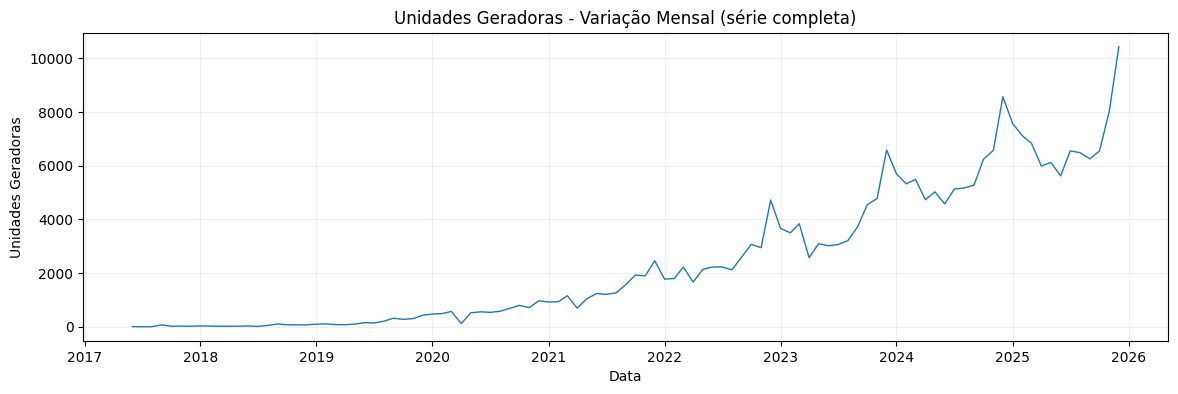

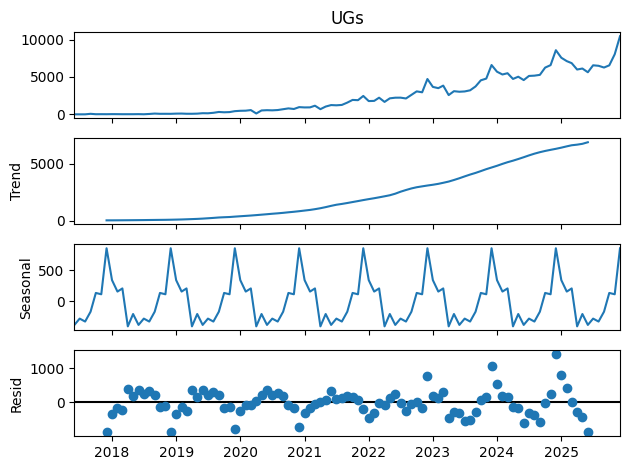

In [11]:
plt.figure(figsize=(14,4))
plt.plot(series, linewidth=1)
plt.title("Unidades Geradoras - Variação Mensal (série completa)")
plt.xlabel("Data")
plt.ylabel("Unidades Geradoras")
plt.grid(True, alpha=0.2)
plt.show()

# Decomposição clássica (apenas exploratória)
decomp = seasonal_decompose(series, model="additive", period=12)
decomp.plot()
plt.show()

In [12]:
def adf_test(x, name="Série"):
    x = x.dropna()
    stat, pval, usedlag, nobs, crit, icbest = adfuller(x, autolag="AIC")
    print(f"--- ADF: {name} ---")
    print("ADF Statistic:", stat)
    print("p-value:", pval)
    print("Critical Values:", crit)
    print()

adf_test(series, "Unidades Geradoras (original)")

# Se não estacionária, aplicar diferença
series_diff = series.diff()
adf_test(series_diff, "Unidades Geradoras (1ª diferença)")

--- ADF: Unidades Geradoras (original) ---
ADF Statistic: 0.8219123883969887
p-value: 0.9919817665019875
Critical Values: {'1%': np.float64(-3.506057133647011), '5%': np.float64(-2.8946066061911946), '10%': np.float64(-2.5844100201994697)}

--- ADF: Unidades Geradoras (1ª diferença) ---
ADF Statistic: -1.3592017896356796
p-value: 0.6016715965742396
Critical Values: {'1%': np.float64(-3.506944401824286), '5%': np.float64(-2.894989819214876), '10%': np.float64(-2.584614550619835)}



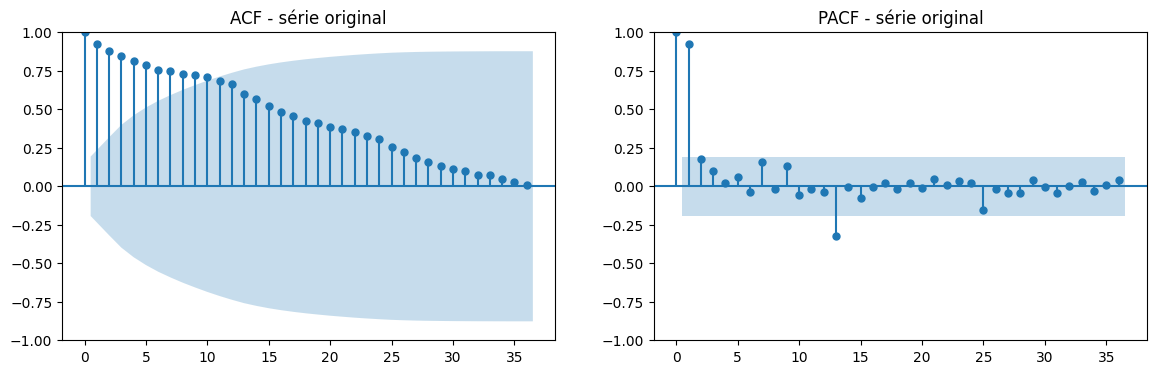

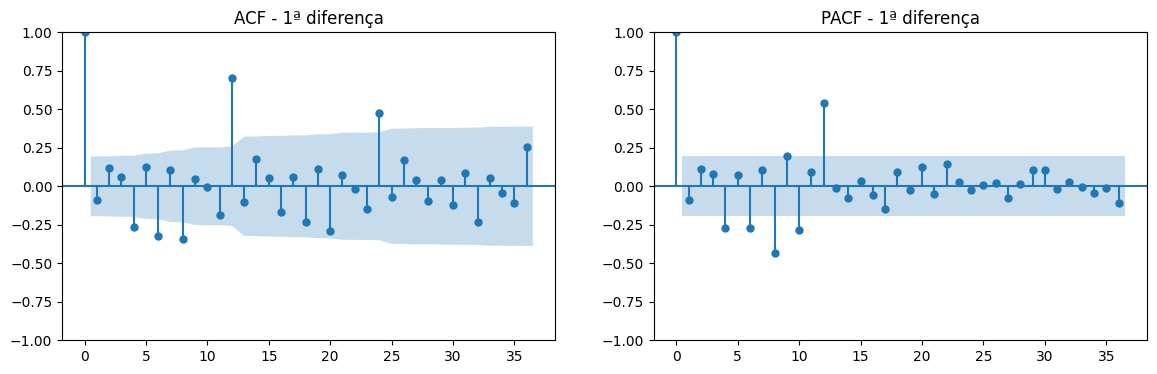

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
plot_acf(series.dropna(), lags=36, ax=ax[0])
plot_pacf(series.dropna(), lags=36, ax=ax[1], method="ywm")
ax[0].set_title("ACF - série original")
ax[1].set_title("PACF - série original")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(14,4))
plot_acf(series_diff.dropna(), lags=36, ax=ax[0])
plot_pacf(series_diff.dropna(), lags=36, ax=ax[1], method="ywm")
ax[0].set_title("ACF - 1ª diferença")
ax[1].set_title("PACF - 1ª diferença")
plt.show()

In [14]:
def lag_features(s, n_lags=12):
    df_ = pd.DataFrame({"y": s})
    for i in range(1, n_lags+1):
        df_[f"lag_{i}"] = s.shift(i)

    #Features de calendário (opcional, mas costuma ajudar sazonalidade mensal)
    df_["month"] = df_.index.month
    df_["month_sin"] = np.sin(2*np.pi*df_["month"]/12)
    df_["month_cos"] = np.cos(2*np.pi*df_["month"]/12)
    df_["year"] = df_.index.year

    df_ = df_.drop(columns = ['month','year'])
    return df_.dropna()

data_ml = lag_features(series, n_lags=12)
print(f"Linhas após adição das features: {data_ml.shape[0]}\nColunas após adição das features: {data_ml.shape[1]}")
data_ml.head()

Linhas após adição das features: 91
Colunas após adição das features: 15


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,month_sin,month_cos
Data,,,,,,,,,,,,,,,
2018-06-01,30,21.0,20.0,19.0,27.0,31.0,20.0,24.0,19.0,72.0,5.0,2.0,6.0,1.224647e-16,-1.000000e+00
2018-07-01,13,30.0,21.0,20.0,19.0,27.0,31.0,20.0,24.0,19.0,72.0,5.0,2.0,-5.000000e-01,-8.660254e-01
2018-08-01,53,13.0,30.0,21.0,20.0,19.0,27.0,31.0,20.0,24.0,19.0,72.0,5.0,-8.660254e-01,-5.000000e-01
2018-09-01,105,53.0,13.0,30.0,21.0,20.0,19.0,27.0,31.0,20.0,24.0,19.0,72.0,-1.000000e+00,-1.836970e-16
2018-10-01,73,105.0,53.0,13.0,30.0,21.0,20.0,19.0,27.0,31.0,20.0,24.0,19.0,-8.660254e-01,5.000000e-01


In [15]:
# últimos 12 meses como teste
h = 12
train_ml = data_ml.iloc[:-h]
test_ml  = data_ml.iloc[-h:]

X_train = train_ml.drop(columns=["y"])
y_train = train_ml["y"]

X_test = test_ml.drop(columns=["y"])
y_test = test_ml["y"]

print("Treino:", X_train.shape, "Teste:", X_test.shape)

Treino: (79, 14) Teste: (12, 14)


In [16]:
def metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred).reshape(-1)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE: cuidado se houver zeros (o material alerta para isso)
    denom = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

In [17]:
# Busca simples por AIC
best_aic = np.inf
best_order = None
best_model = None

train_series = series.iloc[:-h]
test_series  = series.iloc[-h:]

for p in range(0,4):
    for d in range(0,2):
        for q in range(0,4):
            try:
                m = ARIMA(train_series, order=(p,d,q)).fit()
                if m.aic < best_aic:
                    best_aic = m.aic
                    best_order = (p,d,q)
                    best_model = m
            except:
                pass

print("Melhor ARIMA:", best_order, "AIC:", best_aic)

pred_arima = best_model.forecast(steps=len(test_series))

c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-inverti

Melhor ARIMA: (1, 1, 3) AIC: 1344.4487443920038


In [18]:
best_aic = np.inf
best_cfg = None
best_sarima = None

s = 6
for p in range(0,3):
    for d in range(0,2):
        for q in range(0,3):
            for P in range(0,2):
                for D in range(0,2):
                    for Q in range(0,2):
                        try:
                            m = SARIMAX(
                                train_series,
                                order=(p,d,q),
                                seasonal_order=(P,D,Q,s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)
                            if m.aic < best_aic:
                                best_aic = m.aic
                                best_cfg = (p,d,q,P,D,Q,s)
                                best_sarima = m
                        except:
                            pass

print("Melhor SARIMA:", best_cfg, "AIC:", best_aic)

pred_sarima = best_sarima.forecast(steps=len(test_series))

c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Melhor SARIMA: (2, 1, 2, 1, 1, 1, 6) AIC: 1040.6377322584722


c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [20]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [21]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror"
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [22]:
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=1500,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=30
    ))
])
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
# Preparar dados apenas com lags (sem year/month) para sequência
lag_cols = [c for c in data_ml.columns if c.startswith("lag_")]
data_lstm = data_ml[["y"] + lag_cols].copy()

train_lstm = data_lstm.iloc[:-h]
test_lstm  = data_lstm.iloc[-h:]

# Escalar (LSTM costuma precisar)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_lstm)
test_scaled  = scaler.transform(test_lstm)

# Criar X (timesteps, features) e y
# Usando 12 lags como "passos" e 1 feature por passo
def to_seq(mat):
    y = mat[:, 0]
    X = mat[:, 1:]               # lags
    X = X.reshape((X.shape[0], X.shape[1], 1))  # (amostras, 12, 1)
    return X, y

Xtr, ytr = to_seq(train_scaled)
Xte, yte = to_seq(test_scaled)

tf.random.set_seed(42)

model = Sequential([
    LSTM(32, input_shape=(Xtr.shape[1], Xtr.shape[2])),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(patience=20, restore_best_weights=True)

model.fit(Xtr, ytr, epochs=200, batch_size=32, verbose=0, callbacks=[es])

pred_lstm_scaled = model.predict(Xte, verbose=0).reshape(-1)

# "Desescalar": precisamos reconstruir a linha (y + lags) para inverter
tmp = test_scaled.copy()
tmp[:, 0] = pred_lstm_scaled
pred_lstm = scaler.inverse_transform(tmp)[:, 0]

c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\joao.barbosa\anaconda3\envs\forecast_ugs\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


In [27]:
# Métricas de ML/DL (y_test)
rows = []

def add_row(name, y_true, y_pred):
    mae, rmse, mape, r2 = metrics(y_true, y_pred)
    rows.append([name, mae, rmse, mape, r2])

# Estatísticos
add_row("ARIMA",  test_series.values, pred_arima.values)
add_row("SARIMA", test_series.values, pred_sarima.values)

# ML
add_row("Decision Tree", y_test.values, pred_dt)
add_row("Random Forest", y_test.values, pred_rf)
add_row("XGBoost",       y_test.values, pred_xgb)
add_row("MLP",           y_test.values, pred_mlp)

# DL
add_row("LSTM", y_test.values, pred_lstm)

results = pd.DataFrame(rows, columns=["Modelo", "MAE", "RMSE", "MAPE (%)", "R2"])
results = results.sort_values("RMSE")
results.to_csv("output_model_comparison.csv", index=False)

Melhor modelo por RMSE: SARIMA


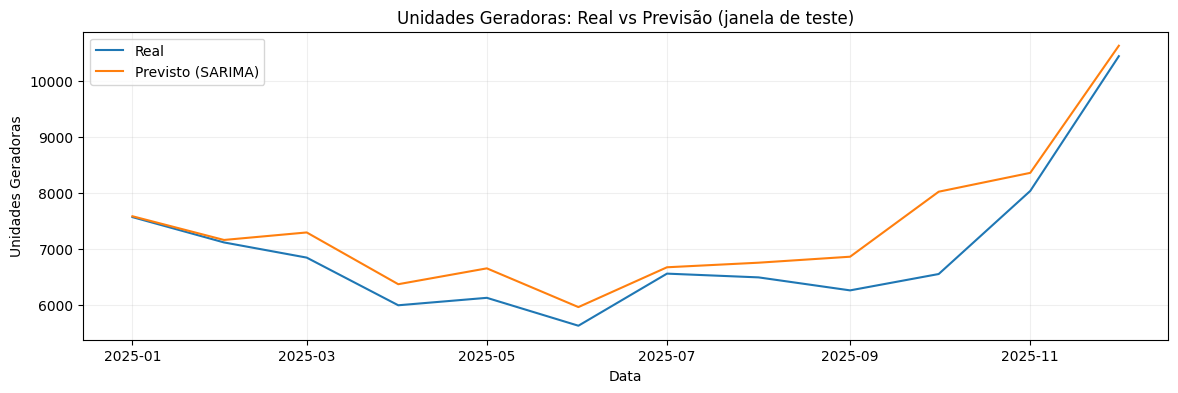

In [25]:
best_model_name = results.iloc[0]["Modelo"]
print("Melhor modelo por RMSE:", best_model_name)

pred_map = {
    "ARIMA": pred_arima.values,
    "SARIMA": pred_sarima.values,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "XGBoost": pred_xgb,
    "MLP": pred_mlp,
    "LSTM": pred_lstm
}

y_true = test_series.values  # mesma janela
y_pred = pred_map[best_model_name]

plt.figure(figsize=(14,4))
plt.plot(test_series.index, y_true, label="Real")
plt.plot(test_series.index, y_pred, label=f"Previsto ({best_model_name})")
plt.title("Unidades Geradoras: Real vs Previsão (janela de teste)")
plt.xlabel("Data")
plt.ylabel("Unidades Geradoras")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

In [26]:
# Avaliar também no treino (somente para ML/DL, onde faz sentido)
def train_test_overfit_check(name, model_predict_train, model_predict_test):
    tr_mae, tr_rmse, tr_mape, tr_r2 = metrics(y_train.values, model_predict_train)
    te_mae, te_rmse, te_mape, te_r2 = metrics(y_test.values, model_predict_test)
    return pd.DataFrame({
        "Modelo":[name],
        "RMSE_treino":[tr_rmse],
        "RMSE_teste":[te_rmse],
        "R2_treino":[tr_r2],
        "R2_teste":[te_r2],
        "MAE_treino":[tr_mae],
        "MAE_teste":[te_mae],
        "MAPE_treino":[tr_mape],
        "MAPE_teste":[te_mape]
    })

overfit_rows = []
overfit_rows.append(train_test_overfit_check("Decision Tree", dt.predict(X_train), pred_dt))
overfit_rows.append(train_test_overfit_check("Random Forest", rf.predict(X_train), pred_rf))
overfit_rows.append(train_test_overfit_check("XGBoost", xgb.predict(X_train), pred_xgb))
overfit_rows.append(train_test_overfit_check("MLP", mlp.predict(X_train), pred_mlp))

overfit_table = pd.concat(overfit_rows, ignore_index=True)
overfit_table.to_csv("output_overfit_check.csv", index=False)